In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score
)

pd.set_option("display.width", 120)
print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
df = pd.read_csv("yaleemmlc_admissionprediction_triage.csv")
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Loaded 46650 patients and 226 columns.


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
TARGET = "esi"

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

X = df[FEATURES]
y = df[TARGET]

print("Model will use", len(FEATURES), "features to predict:", TARGET)

Model will use 209 features to predict: esi


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

Training patients: 37320
Testing patients:  9330


In [5]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
print("Dummy baseline accuracy:", dummy.score(X_test, y_test))

Dummy baseline accuracy: 0.3763129689174705


In [6]:
# Some features may contain stray NaNs after coercion — impute with median first
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

logreg_accuracy = logreg.score(X_test_scaled, y_test)
print(f"Logistic Regression Accuracy: {logreg_accuracy:.3f}")

Logistic Regression Accuracy: 0.669


In [7]:
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

tree_accuracy = tree.score(X_test, y_test)
print(f"Decision Tree Accuracy: {tree_accuracy:.3f}")

Decision Tree Accuracy: 0.563


In [8]:
pred_logreg = logreg.predict(X_test_scaled)
pred_tree = tree.predict(X_test)

print("Example predictions (logreg):", pred_logreg[:10])
print("Example predictions (decision tree):", pred_tree[:10])

Example predictions (logreg): [3. 3. 4. 3. 2. 3. 3. 3. 2. 3.]
Example predictions (decision tree): [3. 3. 3. 3. 2. 3. 3. 3. 3. 3.]


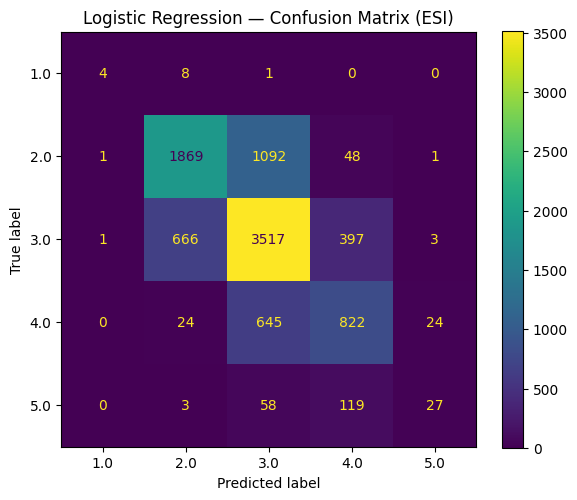

In [9]:
os.makedirs("docs", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax)
ax.set_title("Logistic Regression — Confusion Matrix (ESI)")
plt.tight_layout()
plt.savefig("docs/w6_confusion_logreg.png", dpi=120, bbox_inches="tight")
plt.show()

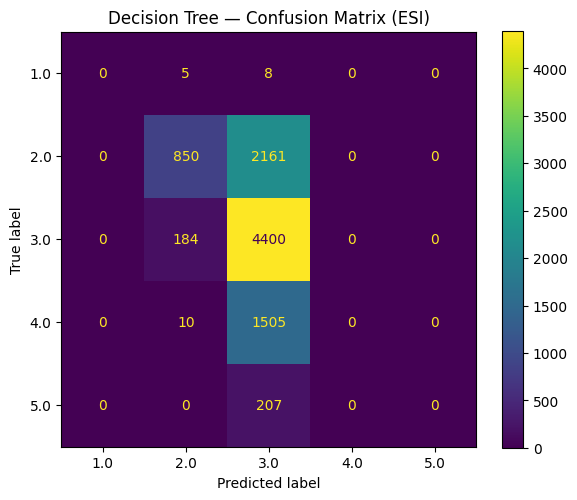

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_tree, ax=ax)
ax.set_title("Decision Tree — Confusion Matrix (ESI)")
plt.tight_layout()
plt.savefig("docs/w6_confusion_tree.png", dpi=120, bbox_inches="tight")
plt.show()

In [11]:
print("===== Logistic Regression =====")
print(classification_report(y_test, pred_logreg, digits=3))

print("\n===== Decision Tree =====")
print(classification_report(y_test, pred_tree, digits=3))

===== Logistic Regression =====
              precision    recall  f1-score   support

         1.0      0.667     0.308     0.421        13
         2.0      0.727     0.621     0.670      3011
         3.0      0.662     0.767     0.711      4584
         4.0      0.593     0.543     0.567      1515
         5.0      0.491     0.130     0.206       207

    accuracy                          0.669      9330
   macro avg      0.628     0.474     0.515      9330
weighted avg      0.668     0.669     0.663      9330


===== Decision Tree =====
              precision    recall  f1-score   support

         1.0      0.000     0.000     0.000        13
         2.0      0.810     0.282     0.419      3011
         3.0      0.531     0.960     0.684      4584
         4.0      0.000     0.000     0.000      1515
         5.0      0.000     0.000     0.000       207

    accuracy                          0.563      9330
   macro avg      0.268     0.248     0.221      9330
weighted avg      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
for name, preds in [("Logistic Regression", pred_logreg), ("Decision Tree", pred_tree)]:
    macro_f1 = f1_score(y_test, preds, average="macro")
    weighted_f1 = f1_score(y_test, preds, average="weighted")
    esi1_recall = recall_score(y_test, preds, labels=[1], average=None)[0]

    print(f"--- {name} ---")
    print(f"Macro F1:     {macro_f1:.3f}")
    print(f"Weighted F1:  {weighted_f1:.3f}")
    print(f"ESI-1 Recall: {esi1_recall:.3f}\n")

--- Logistic Regression ---
Macro F1:     0.515
Weighted F1:  0.663
ESI-1 Recall: 0.308

--- Decision Tree ---
Macro F1:     0.221
Weighted F1:  0.471
ESI-1 Recall: 0.000

